# 1. Breast Cancer Classification Analysis

## Programming for Data Analytics (PDAN8411)

### Part 2 — Classification and Model Improvement

This project aims to develop a machine learning classification model capable of predicting whether a breast tumour is malignant or benign using diagnostic measurements from the Breast Cancer Wisconsin Diagnostic Dataset.

The analysis includes:
- exploratory data analysis (EDA)
- data cleaning
- feature analysis
- multicollinearity assessment
- outlier detection
- preprocessing considerations
- healthcare-focused model preparation

The final goal is to support healthcare decision-making through reliable and interpretable machine learning classification.

# 2. Import Libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# 3. Load Dataset

In [3]:
# Load dataset
df = pd.read_csv("Breast Cancer Data.csv")

# Display first five rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Loading the Dataset

The Breast Cancer Wisconsin Diagnostic Dataset was loaded into the notebook using pandas.

The first five rows were displayed to inspect the dataset structure and verify that the data loaded successfully.

# 4. Dataset Structure Inspection

## 4.1 Dataset Shape

In [4]:
# Dataset dimensions
df.shape

(569, 33)

## Dataset Dimensions

The dataset dimensions were inspected to determine the number of observations and variables available for analysis.

Understanding dataset size is important for evaluating whether sufficient information exists for reliable machine learning model training.

So now we know the following about our data:

The dataset contains 569 observations and 33 columns. This indicates that the dataset is moderately sized and suitable for machine learning analysis. The columns include diagnostic measurements, the target classification variable, and some non-predictive attributes that may require removal during preprocessing.

## 4.2 Dataset Information

In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## Dataset Information

The dataset structure was inspected to identify:
- variable names
- data types
- missing values
- memory usage

This step helps identify potential preprocessing and cleaning requirements before model development.

The df.info() output shows that the dataset contains 569 observations and 33 columns. Most variables contain complete non-null values, indicating good overall data quality with no major missing data concerns. The dataset mainly consists of numerical predictor variables stored as float64, which is suitable for machine learning algorithms. The diagnosis column is stored as an object datatype because it contains categorical labels representing malignant and benign tumour classes. This target variable will require encoding before model training. Additionally, the dataset contains an unnecessary Unnamed: 32 column consisting entirely of null values, as well as an id column that does not contribute predictive information. Both columns will therefore be removed during preprocessing to improve model quality and reduce noise.

## 4.3 Summary Statistics

In [6]:
# Summary statistics
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Statistical Summary

Summary statistics were generated to better understand:
- feature distributions
- central tendencies
- variability
- minimum and maximum values

This helps identify unusual patterns and possible outliers within the dataset.

The statistical summary generated using df.describe() provides important insights into the structure and distribution of the numerical variables within the dataset. Most variables contain 569 observations, indicating that there are no missing values in the primary predictor features. The dataset contains continuous numerical measurements describing tumour characteristics such as radius, texture, perimeter, area, smoothness, and concavity.

The summary statistics show noticeable variation between tumour measurements, particularly for variables such as area_mean and area_worst, which display relatively large standard deviations and wide ranges between minimum and maximum values. This suggests significant differences between tumour samples and indicates that some features may contribute strongly to tumour classification.

The quartile values provide insight into the distribution of the data and help identify potential outliers. Certain features display large gaps between the upper quartile and maximum values, suggesting that outlier analysis will be important during exploratory data analysis.

Additionally, the variables exist on different numerical scales, meaning feature scaling will likely be required before training machine learning algorithms such as Logistic Regression. The summary also confirms that the Unnamed: 32 column contains no valid observations and should therefore be removed during preprocessing.

# 5. Data Cleaning

## 5.1 Missing Value Analysis

In [7]:
# Missing values
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

## Missing Value Assessment

The dataset was evaluated for missing values and incomplete observations.

Missing data can negatively affect machine learning model performance and may require imputation or removal during preprocessing.

The df.isnull().sum() output was used to identify missing values within the dataset. The results show that all primary predictor variables and the target variable contain zero missing values, indicating strong overall data quality and completeness. This means that no additional missing value imputation techniques are required before model training.

However, the column Unnamed: 32 contains 569 null values, meaning the entire column is empty and provides no meaningful analytical or predictive information. This column will therefore be removed during preprocessing to improve dataset quality and reduce unnecessary noise within the analysis.

## 5.2 Remove Unnecessary Columns

In [8]:
# Remove unnecessary columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# Confirm changes
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Removing Irrelevant Variables

The columns `id` and `Unnamed: 32` were removed from the dataset.

Reasons:
- `id` acts only as a unique identifier and provides no predictive value
- `Unnamed: 32` contains entirely null values

Removing irrelevant features helps reduce noise and improve model performance.

# 6. Target Variable Assessment

## 6.1 Inspect Diagnosis Variable

In [9]:
# Diagnosis distribution
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

## 6.2 Visualise Diagnosis Distribution

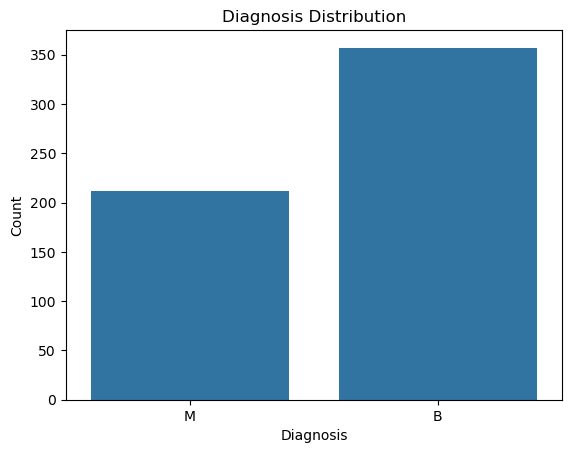

In [10]:
sns.countplot(x='diagnosis', data=df)

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

## Target Variable Analysis

The diagnosis variable was analysed to evaluate the distribution of:
- malignant tumours (M)
- benign tumours (B)

Class balance is important in healthcare classification because severe imbalance may negatively affect predictive reliability and increase the risk of false negative predictions.

The diagnosis distribution analysis shows that the dataset contains 357 benign tumour cases and 212 malignant tumour cases. This indicates that the dataset is slightly imbalanced, with benign cases representing the majority class. Although the imbalance is not severe, it remains an important consideration because class imbalance can influence machine learning model performance.

In healthcare classification tasks such as cancer diagnosis, false negative predictions are especially dangerous because incorrectly classifying a malignant tumour as benign may delay treatment and negatively affect patient outcomes. For this reason, evaluation metrics such as recall, precision, F1-score, and confusion matrices will be important during model evaluation rather than relying solely on accuracy.

Overall, both diagnosis classes remain sufficiently represented, meaning the dataset is still appropriate for binary classification modelling.

# 7. Classification Suitability Discussion

## Suitability for Classification

Unlike linear regression problems that require a continuous numerical target variable, this dataset contains a binary categorical target variable.

The diagnosis column contains:
- malignant tumour classifications
- benign tumour classifications

This makes the dataset highly suitable for classification algorithms such as Logistic Regression.

# 8. Encode Target Variable

In [11]:
# Encode diagnosis variable
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})

# Confirm encoding
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Encoding the Target Variable

The diagnosis variable was converted into numerical values:
- Malignant = 1
- Benign = 0

Machine learning algorithms require numerical input values for training and prediction.

# Feature Relationship Analysis

## 9.1 Correlation with Target Variable

In [12]:
# Correlation with diagnosis
correlation_target = df.corr()['diagnosis'].sort_values(ascending=False)

correlation_target

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

## Feature Relevance Assessment

Correlation analysis was performed to evaluate relationships between predictor variables and tumour diagnosis.

Features showing stronger relationships with the diagnosis variable may contribute more effectively to classification performance.

The correlation analysis was performed to identify which tumour characteristics are most strongly associated with the diagnosis variable. The results show that several features, particularly concave points_worst, perimeter_worst, radius_worst, perimeter_mean, and area_worst, have strong positive correlations with tumour diagnosis. This suggests that malignant tumours are generally associated with larger, more irregular, and more complex cell structures.

Features related to tumour radius, perimeter, area, and concavity appear to provide the strongest predictive value for classification modelling. In contrast, variables such as texture_se, symmetry_se, and fractal_dimension_se display very weak correlations with the target variable, suggesting limited predictive contribution.

The correlation analysis also indicates the possible presence of multicollinearity between certain tumour measurements, particularly among features describing size and shape. This will be considered further during feature selection and model training. Overall, the results confirm that the dataset contains several highly informative predictors suitable for breast cancer classification using machine learning techniques.

## 9.2 Pairplot Analysis

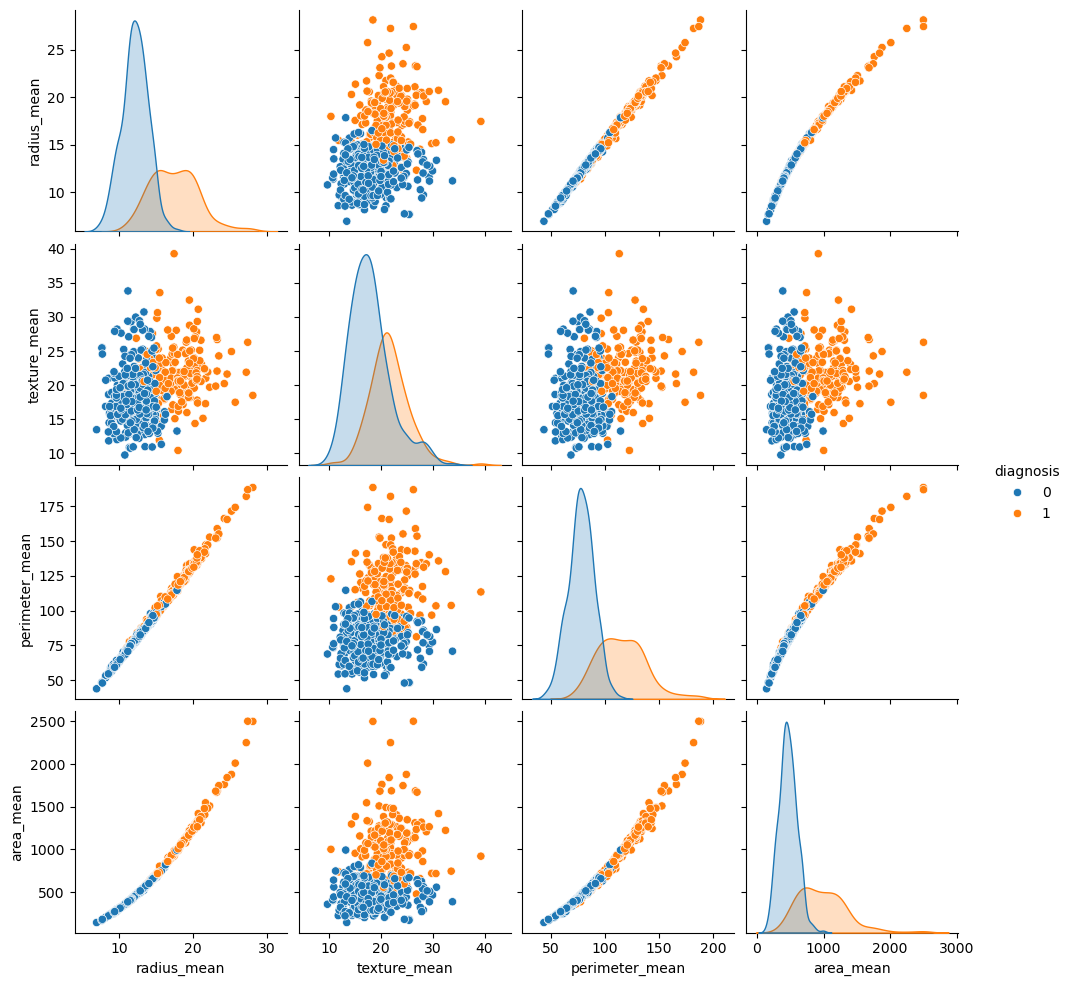

In [13]:
selected_features = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'diagnosis'
]

sns.pairplot(
    df[selected_features],
    hue='diagnosis'
)

plt.show()

## Predictor Relationship Analysis

Pairplots were generated to evaluate how effectively important diagnostic measurements separate malignant and benign tumour classes.

Several variables demonstrate visible separation between classes, suggesting that the dataset contains strong predictive information suitable for classification modelling.

The pairplot was used to visually analyse the relationships between selected tumour features and the diagnosis classification. The visualisations show clear separation between benign and malignant tumour cases, particularly for variables such as radius_mean, perimeter_mean, and area_mean. Malignant tumours generally display larger values for these measurements, indicating that tumour size and structural characteristics are strongly associated with cancer diagnosis.

Strong linear relationships are also visible between radius_mean, perimeter_mean, and area_mean, suggesting the presence of multicollinearity between these variables. This indicates that some features may provide overlapping information and may require consideration during feature selection.

In contrast, texture_mean displays greater overlap between the two diagnosis classes, suggesting that it may be a weaker standalone predictor compared to tumour size-related variables.

The pairplot also reveals a small number of possible outliers with unusually large tumour measurements. Overall, the visualisation confirms that the dataset contains strong predictive patterns and appears highly suitable for binary classification modelling using machine learning techniques.

# 10. Multicollinearity Assessment

## 10.1 Correlation Heatmap

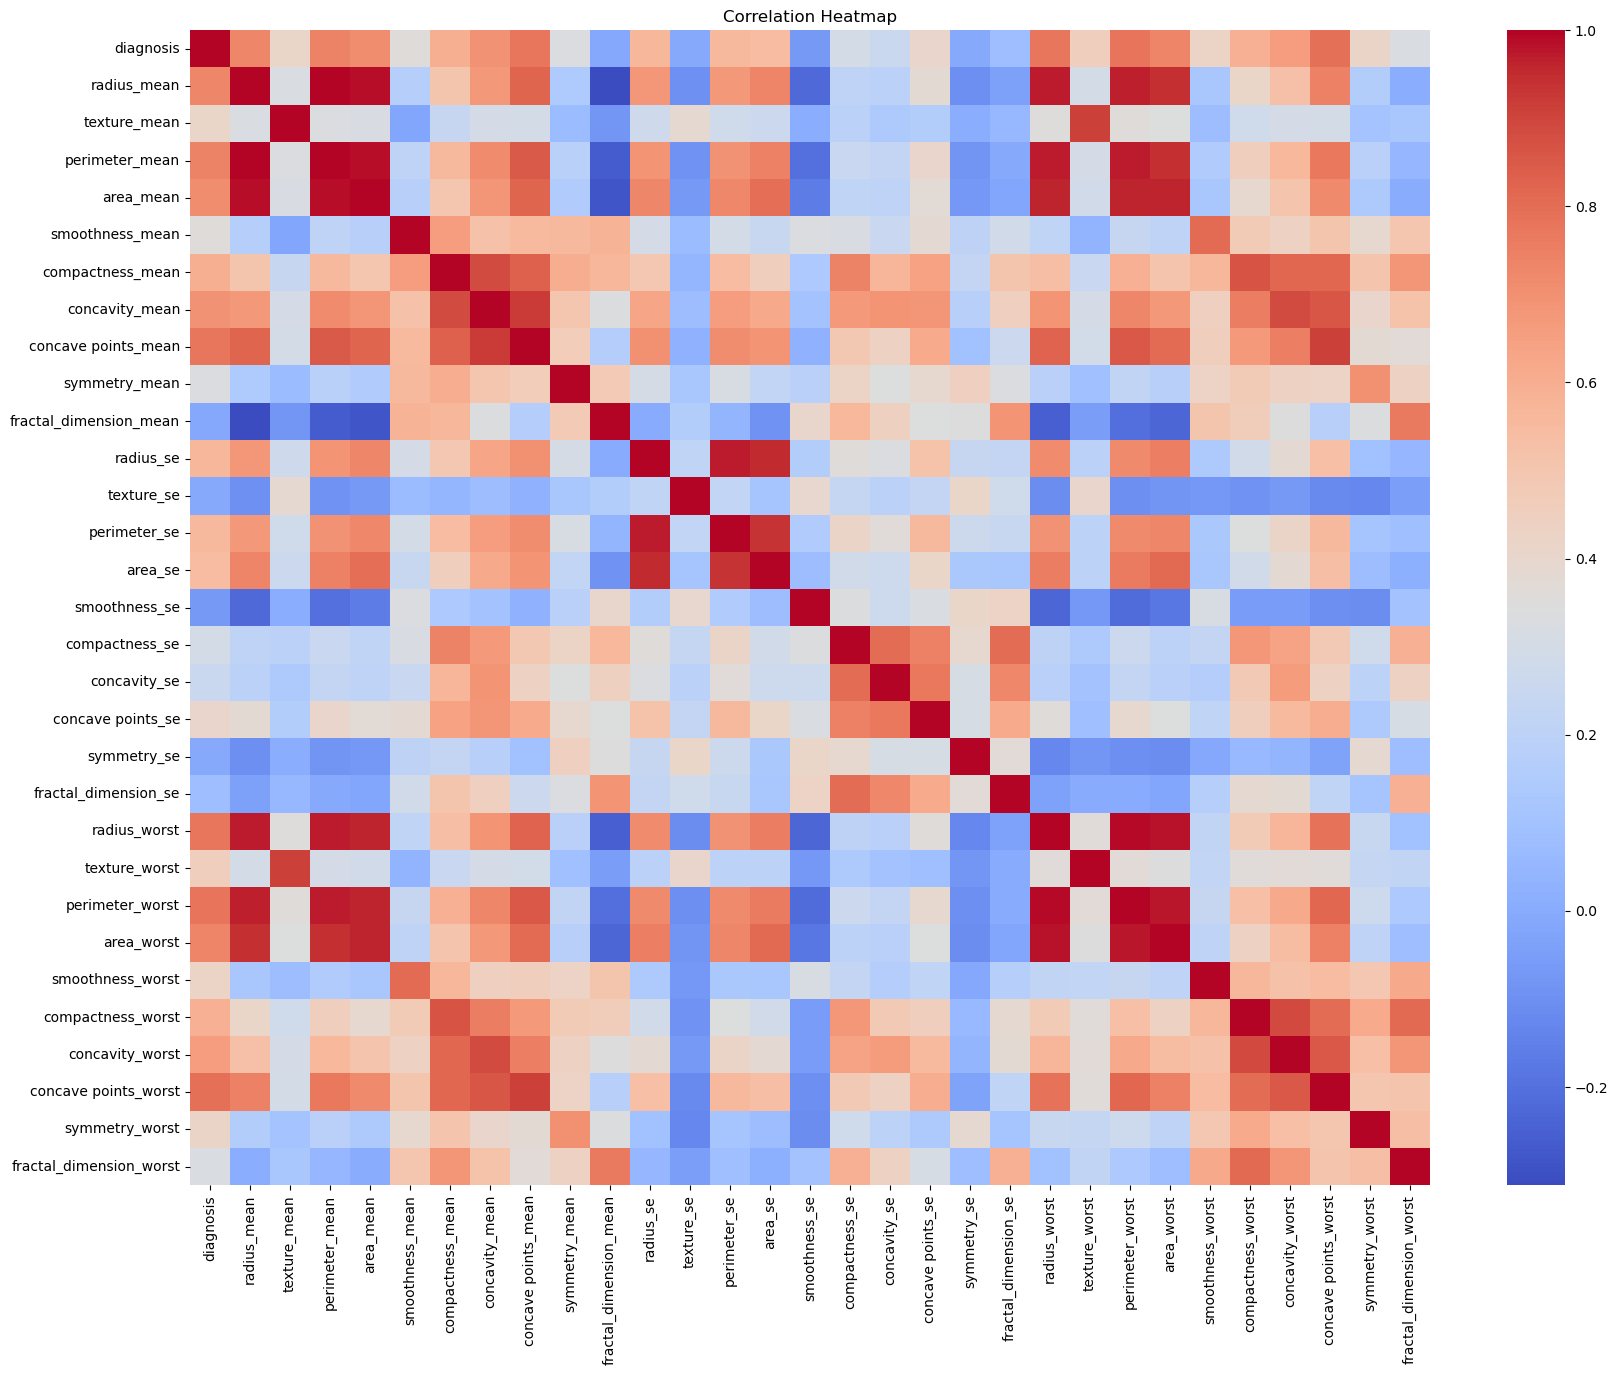

In [16]:
plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

## Multicollinearity Analysis

The correlation heatmap identified several highly correlated predictor variables, particularly among radius, perimeter, and area measurements.

Highly correlated variables may introduce redundancy within machine learning models and reduce interpretability. Feature selection techniques will therefore be considered later in the analysis.

The correlation heatmap was used to analyse the relationships between all numerical variables within the dataset. Several strong positive correlations are visible between tumour size-related variables such as radius_mean, perimeter_mean, and area_mean, as well as their corresponding “worst” measurements. This indicates that these variables increase together and likely describe closely related tumour characteristics.

The heatmap also reveals the presence of multicollinearity between several predictors. Highly correlated variables may introduce redundancy into machine learning models and reduce interpretability, particularly in Logistic Regression models. Feature selection techniques will therefore be considered to reduce unnecessary overlap between predictors.

Strong positive correlations are also visible between the diagnosis variable and features such as concave points_worst, perimeter_worst, radius_worst, and area_worst. This suggests that tumour size, shape irregularity, and concavity are strongly associated with malignant cancer diagnoses.

In contrast, variables such as symmetry_se, texture_se, and fractal_dimension_se display relatively weak relationships with diagnosis, suggesting lower predictive importance.

Overall, the heatmap confirms that the dataset contains clear and medically meaningful feature relationships, making it highly suitable for machine learning classification analysis.

# 11. Feature Distribution Analysis

## 11.1 Histograms

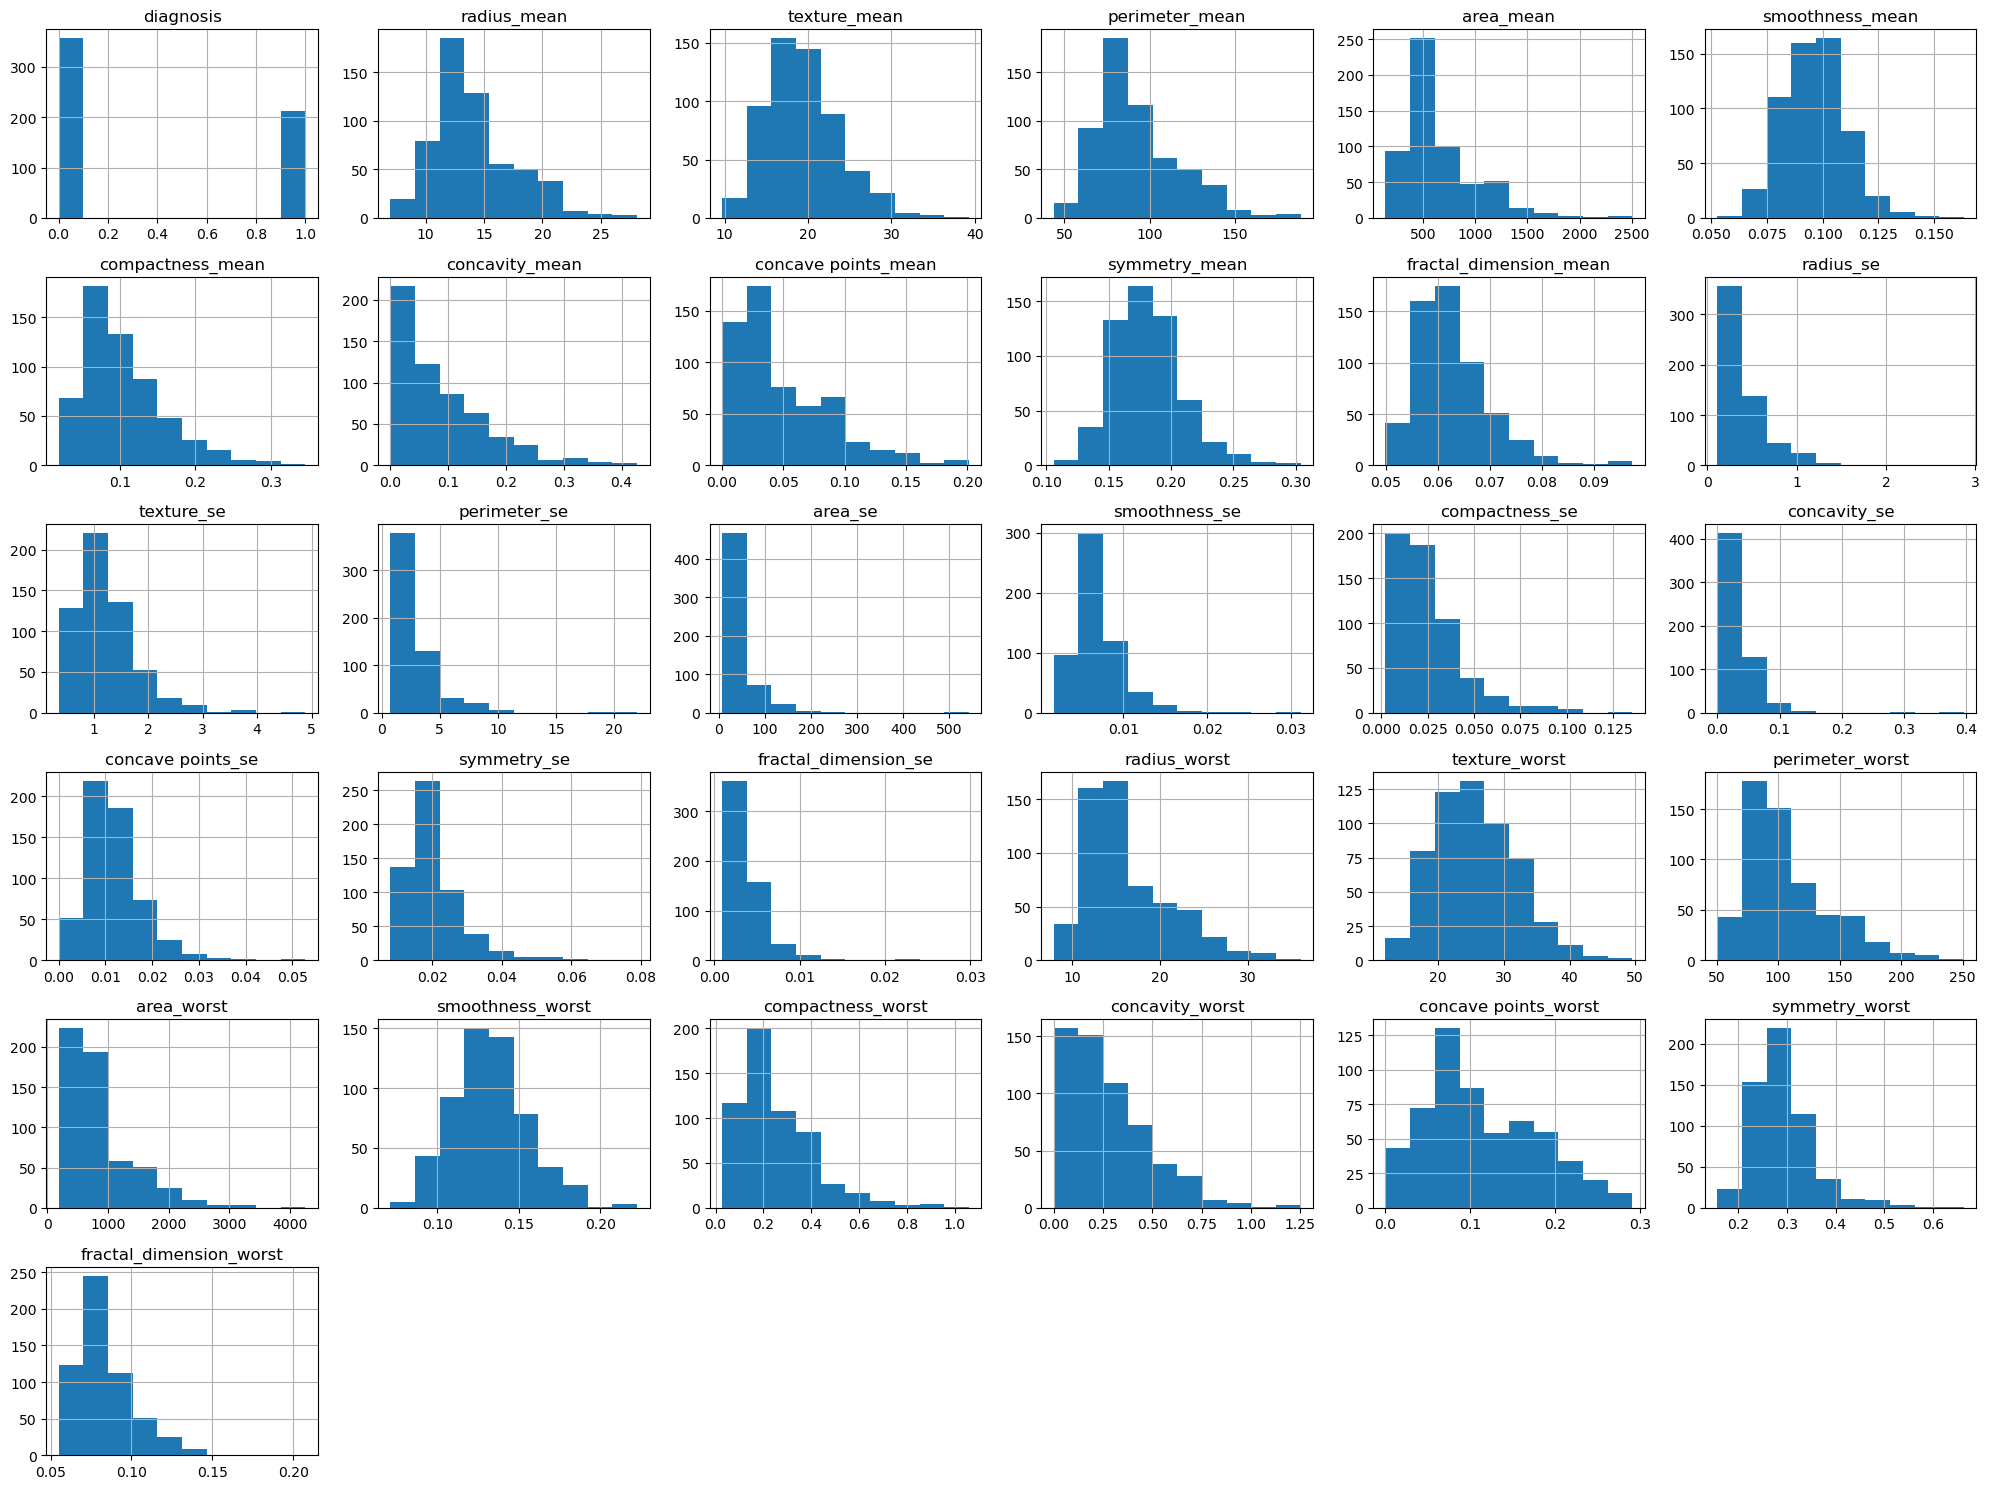

In [18]:
df.hist(figsize=(20,15))

plt.tight_layout()

plt.show()

## Feature Distribution Assessment

Histograms were generated to evaluate:
- feature distributions
- skewness
- variability
- potential abnormal patterns

Understanding feature distributions is important for preprocessing and model preparation.

The feature distribution histograms were used to analyse the distribution and spread of the numerical variables within the dataset. Several features, particularly those related to tumour size and structure such as area_mean, area_worst, perimeter_mean, and concavity_mean, display positively skewed distributions with long right tails. This indicates that most tumour measurements are concentrated at lower values, while a smaller number of observations contain significantly larger values.

The histograms also suggest the presence of potential outliers within certain variables, especially tumour area and perimeter measurements. Outlier analysis will therefore be considered during preprocessing to evaluate whether these extreme values may influence model performance.

Some variables, such as smoothness_mean and symmetry_mean, appear more normally distributed, indicating more balanced feature behaviour. The visualisations also reveal substantial differences in feature scales across the dataset. Variables such as area_worst exist on much larger numerical ranges than variables such as smoothness_mean, suggesting that feature scaling will be necessary before training scale-sensitive machine learning algorithms such as Logistic Regression.

Additionally, the diagnosis distribution confirms that benign tumour cases are more common than malignant cases, although both classes remain sufficiently represented for binary classification analysis.

Overall, the histograms show that the dataset contains meaningful numerical variation and medically relevant patterns suitable for machine learning classification modelling.

# 12. Outlier Detection

## 12.1 Boxplots

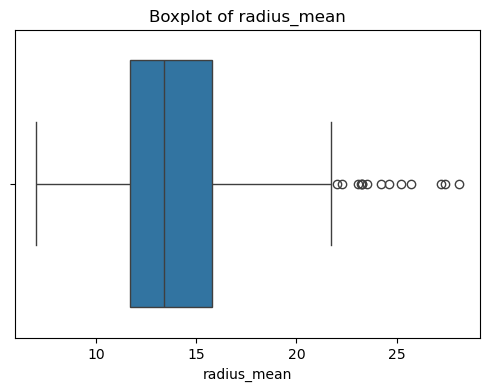

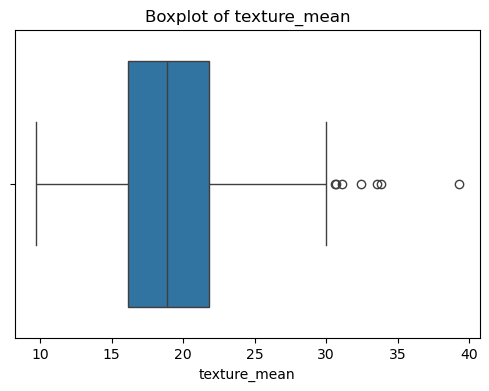

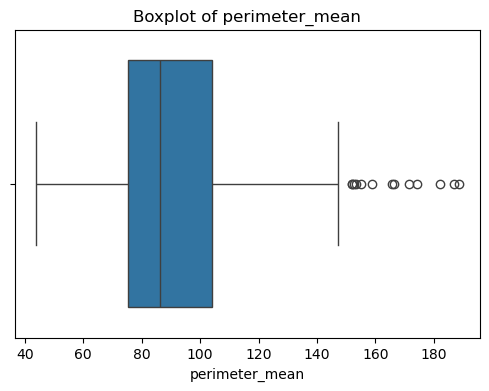

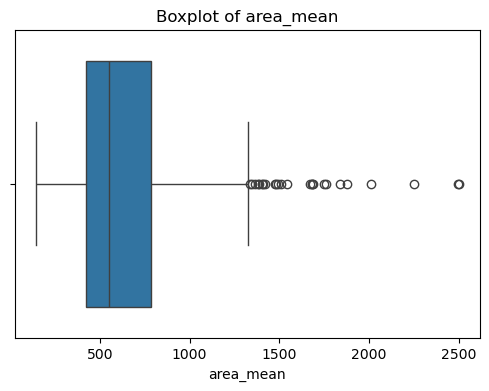

In [20]:
features = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean'
]

for feature in features:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[feature])
    
    plt.title(f'Boxplot of {feature}')
    
    plt.show()

## Outlier Detection

Boxplots were used to identify potential outliers within important diagnostic variables.

Extreme values may distort classification boundaries and negatively affect model generalisation and predictive stability.

The boxplots were used to analyse the spread, central tendency, and presence of outliers within selected tumour measurement variables. All four features display positively skewed distributions with several observations extending beyond the upper whiskers, indicating the presence of potential outliers.

The most extreme outliers appear within area_mean and perimeter_mean, suggesting that some tumour cases contain significantly larger measurements compared to the majority of observations. These extreme values may represent severe malignant tumour cases and therefore should be evaluated carefully rather than removed automatically.

The boxplots also show substantial variability in tumour size-related features such as radius, perimeter, and area, supporting previous findings from the correlation analysis and pairplots that these variables may provide strong predictive value for cancer classification.

In contrast, texture_mean appears less skewed and contains fewer extreme observations, suggesting a more stable distribution with lower variability.

Overall, the visualisations indicate that the dataset contains meaningful variation and some potential outliers, which should be considered during preprocessing and model development. Feature scaling and additional outlier analysis may therefore improve model performance and stability.

# 13. Independence of Observations

## Independence of Observations

Each observation within the dataset represents an independent tumour sample obtained from a separate patient examination.

No repeated measurements or time-dependent observations were identified, suggesting that the assumption of independent observations is satisfied.

# 14. Sample Size Assessment

In [21]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 569
Number of columns: 31


## Sample Size Assessment

The dataset contains a sufficient number of observations relative to the number of predictor variables.

With 569 observations and approximately 31 numerical features, the dataset provides enough information for reliable classification model training and evaluation.

# 15. Feature Scaling Consideration

## Feature Scaling Consideration

The predictor variables exist on different numerical scales.

Feature scaling using StandardScaler will therefore be applied during preprocessing because Logistic Regression and other classification algorithms are sensitive to scale differences.

# 16. Homoscedasticity Discussion

## Homoscedasticity Consideration

Homoscedasticity refers to constant variance of residual errors and is primarily associated with linear regression models.

Since this project focuses on classification rather than predicting continuous numerical values, this assumption is less critical. However, feature distributions and outliers were still evaluated to support stable model performance.

# 17. Normal Distribution Discussion

## Distribution Consideration

Normally distributed residuals are more important in linear regression analysis than in Logistic Regression classification.

However, evaluating feature distributions remains valuable for identifying skewness, unusual patterns, and preprocessing requirements.

# 18. Data Leakage Prevention

## Data Leakage Prevention

Care was taken to avoid data leakage during preprocessing and model training.

Train-test splitting will be performed before feature scaling and model fitting to ensure that information from the testing dataset does not influence the training process.

# 19. Final EDA Summary

## Exploratory Data Analysis Summary

The exploratory data analysis process identified several important findings:

- The dataset is clean, structured, and highly suitable for healthcare classification
- The target variable is appropriately balanced for binary classification
- Several predictors demonstrate strong relationships with tumour diagnosis
- Highly correlated variables indicate possible multicollinearity
- Some outliers are present within certain diagnostic measurements
- Feature scaling will be necessary before model training
- No significant missing data issues were identified after preprocessing

Overall, the dataset demonstrates strong suitability for Logistic Regression classification modelling and healthcare-focused predictive analysis.

# 20. Feature Selection and Preprocessing

## 20.1 Separate Features and Target Variable

In [22]:
# Separate features and target variable

X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

# Display shapes
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


## Separating Features and Target Variable

The dataset was divided into:
- predictor variables (X)
- target variable (y)

The predictor variables contain tumour measurement features used for classification, while the target variable represents the tumour diagnosis outcome.

## 20.2 Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


## Train-Test Split

The dataset was divided into training and testing datasets using an 80/20 split.

This approach allows the model to learn patterns from the training data while evaluating predictive performance on unseen testing data.

Stratified sampling was applied to preserve the original class distribution between malignant and benign tumour cases.

## 20.3 Feature Scaling

In [24]:
# Initialise scaler

scaler = StandardScaler()

# Fit scaler ONLY on training data

X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data

X_test_scaled = scaler.transform(X_test)

## Feature Scaling

Feature scaling was applied using StandardScaler.

Scaling standardises variables onto similar numerical ranges, preventing larger-scale variables from dominating the model.

The scaler was fitted only on the training dataset to prevent data leakage from the testing dataset.

## 20.4 Check Feature Correlations Again

In [25]:
# Correlation with target

correlation_target = df.corr()['diagnosis'].sort_values(
    ascending=False
)

correlation_target

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

## Feature Selection Preparation

Correlation analysis was reviewed to identify features most strongly associated with tumour diagnosis.

Variables with stronger relationships to the target variable may contribute more effectively to classification performance.

The correlation analysis was conducted to determine which tumour characteristics are most strongly associated with cancer diagnosis. The results show that several features, particularly concave points_worst, perimeter_worst, radius_worst, perimeter_mean, and area_worst, display strong positive correlations with the diagnosis variable. This suggests that tumour size, irregularity, and concavity are strongly linked to malignant cancer cases.

Variables related to tumour radius, perimeter, area, and concavity appear to provide the highest predictive value for classification modelling. In contrast, variables such as symmetry_se, texture_se, and fractal_dimension_se display very weak correlations with diagnosis, suggesting lower predictive importance.

The results also indicate the possible presence of multicollinearity between several tumour size-related variables because many highly predictive features are biologically related and likely strongly correlated with one another.

Overall, the analysis confirms that the dataset contains several medically meaningful predictors suitable for machine learning classification tasks.

## 20.5 Identify Highly Correlated Features

In [26]:
# Create correlation matrix

corr_matrix = X.corr().abs()

# Upper triangle matrix

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated features

high_corr_features = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly correlated features:")
print(high_corr_features)

Highly correlated features:
['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


## Multicollinearity Reduction

Highly correlated predictor variables were identified using correlation threshold analysis.

Features with correlations above 0.90 may introduce redundancy into Logistic Regression models and reduce interpretability.

## 20.6 Removal of Highly Correlated Features

## Handling Multicollinearity

The correlation analysis identified several highly correlated predictor variables, particularly among tumour size-related measurements such as radius, perimeter, and area.

Although high multicollinearity may introduce redundancy and reduce interpretability within Logistic Regression models, the features were retained during the initial model training stage for several reasons:

- many of the correlated variables contain medically meaningful diagnostic information
- Logistic Regression can still perform effectively despite moderate multicollinearity
- retaining all predictors allows the baseline model to utilise the full diagnostic information available within the dataset
- the purpose of the initial model is to establish baseline classification performance before applying more advanced feature selection techniques

The impact of multicollinearity will continue to be monitored during model evaluation and future feature selection stages.

## 20.7 Final Preprocessing Summary

## Preprocessing Summary

The preprocessing stage included:
- separating predictor and target variables
- train-test splitting
- feature scaling
- multicollinearity investigation
- feature relevance analysis

These steps help improve model reliability, reduce data leakage risk, and prepare the dataset for machine learning classification.

# 21 Baseline Logistic Regression Model

## 21.1 Import Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

## 21.2 Train Logistic Regression Model

In [28]:
# Initialise Logistic Regression model

logreg = LogisticRegression(
    max_iter=10000,
    random_state=42
)

# Train model

logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000, random_state=42)

## 21.3 Generate Predictions

In [29]:
# Generate predictions

y_pred = logreg.predict(X_test_scaled)

# Display predictions

y_pred[:10]

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0], dtype=int64)

## Logistic Regression Model Training

A baseline Logistic Regression classification model was trained using the scaled training dataset.

Logistic Regression was selected because:
- the project involves binary classification
- the model is highly interpretable
- it performs effectively on structured healthcare datasets
- the algorithm provides probabilistic predictions useful for medical decision-making

The model was initially trained using all available predictor variables to establish baseline classification performance before applying advanced feature selection and optimisation techniques.

# 22 Baseline Model Evaluation

## 22.1 Accuracy Score

In [30]:
from sklearn.metrics import accuracy_score

# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


## Accuracy Evaluation

Accuracy was calculated to measure the overall proportion of correctly classified tumour cases.

Although accuracy provides a useful general performance indicator, it is not sufficient on its own for healthcare classification tasks because false negative predictions may have serious clinical consequences.

The model achieved an accuracy score of approximately 96.49%, indicating that the classification algorithm correctly predicted the diagnosis for the majority of tumour cases within the testing dataset. This suggests that the selected tumour features contain strong predictive patterns capable of effectively distinguishing between malignant and benign tumours.

The high accuracy score demonstrates that the model performs well overall and that the dataset is highly suitable for machine learning classification analysis. However, accuracy alone is not sufficient when evaluating healthcare classification systems because false negative predictions may have serious medical consequences. Additional evaluation metrics such as precision, recall, F1-score, and confusion matrices will therefore also be considered to provide a more comprehensive assessment of model performance.

## 22.2 Classification Report

In [31]:
from sklearn.metrics import classification_report

# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## Classification Report

The classification report provides detailed evaluation metrics including:
- precision
- recall
- F1-score
- support

These metrics provide deeper insight into model behaviour and are especially important in healthcare machine learning applications where correctly identifying malignant tumours is critical.

The classification report shows that the model achieved strong predictive performance across both benign and malignant tumour classes. The overall accuracy score of approximately 96% indicates that the majority of tumour cases were classified correctly.

The model achieved a precision score of 0.97 for malignant tumours, meaning that most tumours predicted as malignant were correctly identified. The recall score for malignant tumours was 0.93, indicating that the model successfully detected approximately 93% of actual cancer cases within the testing dataset.

Recall is particularly important in healthcare classification problems because false negative predictions may delay treatment and negatively affect patient outcomes. The relatively high recall score therefore suggests that the model performs reliably for cancer detection purposes.

The F1-scores for both classes were also high, demonstrating a strong balance between precision and recall. Additionally, both macro and weighted averages remained consistently strong, indicating balanced performance across the dataset despite slight class imbalance.

Overall, the classification report suggests that the model is highly effective at distinguishing between malignant and benign tumours and is well suited for healthcare classification analysis.

## 22.3 Confusion Matrix

In [32]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[71  1]
 [ 3 39]]


## 22.4 Confusion Matrix Heatmap

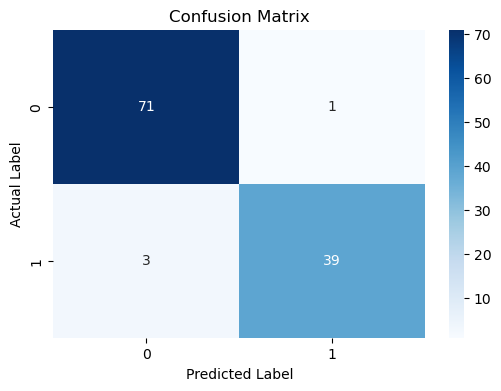

In [33]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title("Confusion Matrix")

plt.show()

## Confusion Matrix Analysis

The confusion matrix was used to evaluate the number of:
- true positives
- true negatives
- false positives
- false negatives

In breast cancer classification, false negatives are particularly dangerous because they represent malignant tumours incorrectly classified as benign.

Minimising false negative predictions is therefore extremely important for maintaining reliable healthcare decision-making.

The confusion matrix provides a detailed breakdown of the model’s classification performance for benign and malignant tumour cases. The model correctly classified 71 benign tumours and 39 malignant tumours, demonstrating strong predictive performance overall.

Only one benign tumour was incorrectly classified as malignant, while three malignant tumours were incorrectly classified as benign. These incorrect malignant predictions represent false negatives, which are particularly important in healthcare classification because missed cancer diagnoses may delay treatment and negatively affect patient outcomes.

Despite the small number of false negatives, the model still demonstrates strong cancer detection capability with relatively few classification errors overall. The confusion matrix therefore supports the high accuracy, precision, recall, and F1-scores observed during model evaluation.

Overall, the results suggest that the classification model is highly effective at distinguishing between malignant and benign tumours and is suitable for healthcare-related prediction tasks.

## 22.5 Precision, Recall, and F1-Score Discussion

In [34]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Calculate metrics

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

# Print metrics

print("Precision:", precision)

print("Recall:", recall)

print("F1-Score:", f1)

Precision: 0.975
Recall: 0.9285714285714286
F1-Score: 0.9512195121951219


## Precision, Recall, and F1-Score

Precision measures how many tumours predicted as malignant were actually malignant.

Recall measures how effectively the model identifies malignant tumour cases.

F1-score provides a balance between precision and recall.

In healthcare classification problems such as breast cancer diagnosis, recall is especially important because failing to identify malignant tumours may negatively affect patient treatment outcomes.

The model achieved a precision score of 97.5%, indicating that the vast majority of tumours predicted as malignant were correctly classified. This suggests that the model produces highly reliable positive cancer predictions with very few false positives.

The recall score of approximately 92.86% indicates that the model successfully identified most malignant tumour cases within the testing dataset. Recall is particularly important in healthcare classification problems because false negative predictions may delay treatment and negatively affect patient outcomes.

The F1-score of approximately 95.12% demonstrates a strong balance between precision and recall, indicating that the model performs consistently well when distinguishing between malignant and benign tumours.

Overall, these evaluation metrics suggest that the classification model is highly effective, reliable, and well suited for healthcare-related cancer prediction tasks.

## 22.6 Baseline Evaluation Summary

## Baseline Model Evaluation Summary

The baseline Logistic Regression model demonstrated strong classification performance on the breast cancer dataset.

The evaluation metrics indicate that the model is capable of effectively distinguishing between malignant and benign tumour cases. Recall performance is particularly important in this healthcare context because correctly identifying malignant tumours reduces the risk of delayed diagnosis and treatment.

Overall, the baseline model provides a strong foundation for further optimisation, feature selection, and hyperparameter tuning.

# 23 ROC Curve and AUC Analysis

## 23.1 Generate Prediction Probabilities

In [35]:
# Generate prediction probabilities

y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

## Prediction Probabilities

Prediction probabilities were generated to estimate the likelihood that a tumour belongs to the malignant class.

Probability-based outputs provide more detailed insight into model confidence and are required for ROC curve and AUC evaluation.

## 23.2 Import ROC Metrics

In [36]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

## 23.3 Calculate ROC Curve

In [37]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

## 23.4 Calculate AUC Score

In [38]:
# Calculate AUC score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.996031746031746


## Area Under the Curve (AUC)

The Area Under the Curve (AUC) measures the model’s ability to distinguish between malignant and benign tumour cases.

Higher AUC values indicate stronger classification performance and improved separation between diagnosis classes.

The model achieved an AUC score of approximately 0.996, indicating extremely strong classification performance. The Area Under the ROC Curve (AUC) measures the model’s ability to distinguish between malignant and benign tumour cases across different classification thresholds.

An AUC score close to 1.0 indicates near-perfect class separation, meaning the model is highly effective at assigning higher prediction probabilities to malignant tumours compared to benign tumours. This suggests that the selected tumour features contain very strong predictive information and that the classification model generalises well to unseen data.

In healthcare-related machine learning tasks, AUC is particularly valuable because it evaluates the balance between true positive rates and false positive rates rather than relying solely on accuracy. The exceptionally high AUC score therefore provides strong evidence that the model is reliable and highly suitable for breast cancer classification analysis.

## 23.5 Plot ROC Curve

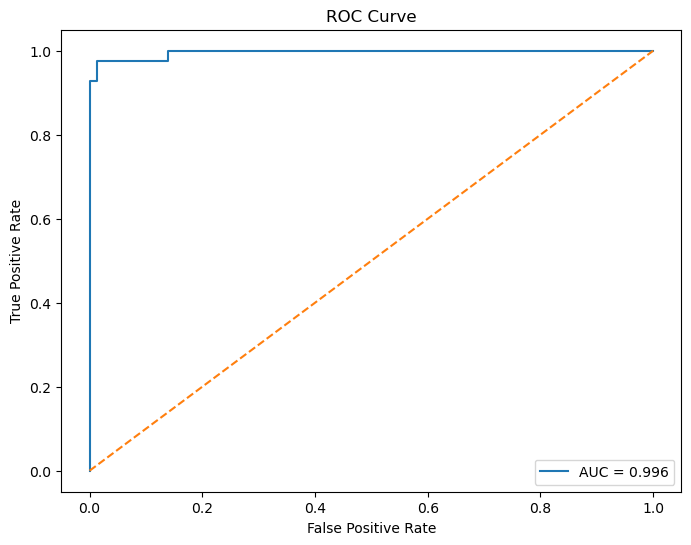

In [39]:
plt.figure(figsize=(8,6))

# Plot ROC curve

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc_score:.3f}'
)

# Random baseline

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

# Labels

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## ROC Curve Analysis

The ROC curve was used to evaluate the classification performance of the Logistic Regression model across multiple probability thresholds.

The curve demonstrates the trade-off between:
- true positive rate (sensitivity)
- false positive rate

A curve positioned closer to the upper-left corner indicates stronger classification performance and improved ability to distinguish between malignant and benign tumours.

The ROC Curve demonstrates the model’s ability to distinguish between malignant and benign tumour cases across different classification thresholds. The curve rises sharply toward the top-left corner of the graph, indicating that the model achieves a high true positive rate while maintaining a very low false positive rate.

The model achieved an AUC score of approximately 0.996, which indicates near-perfect classification performance. This suggests that the model can effectively separate malignant tumours from benign tumours with extremely high reliability.

In healthcare machine learning applications, ROC curves are particularly useful because they evaluate classification performance across multiple thresholds rather than relying solely on accuracy. The exceptionally high AUC score therefore provides strong evidence that the model generalises well to unseen data and is highly suitable for breast cancer classification analysis.

Overall, the ROC Curve confirms that the selected features contain strong predictive information and that the classification model performs exceptionally well for healthcare-related tumour diagnosis tasks.

## 23.6 Healthcare Interpretation of ROC-AUC

## Healthcare Interpretation

In healthcare classification tasks such as breast cancer diagnosis, strong ROC-AUC performance is particularly important because it reflects the model’s ability to correctly identify malignant tumour cases while minimising incorrect classifications.

A high AUC score suggests that the model demonstrates strong discriminatory capability and may provide valuable support for medical decision-making processes.

## 23.7 ROC-AUC Summary

## ROC-AUC Summary

The ROC curve and AUC analysis indicate that the Logistic Regression model demonstrates strong classification capability on the breast cancer dataset.

The model shows effective separation between malignant and benign tumour classes, supporting its suitability for healthcare-focused predictive analysis.

## 24 Feature Selection Using RFE

## 24.1 Import RFE

In [40]:
from sklearn.feature_selection import RFE

## 24.2 Initialise Logistic Regression Model for RFE

In [41]:
# Create Logistic Regression model

logreg_rfe = LogisticRegression(
    max_iter=10000,
    random_state=42
)

We created a new model because it:
- keeps workflow organised
- separates baseline model from feature selection stage

## 24.3 Apply Recursive Feature Elimination

In [42]:
# Initialise RFE

rfe = RFE(
    estimator=logreg_rfe,
    n_features_to_select=10
)

# Fit RFE

rfe.fit(X_train_scaled, y_train)

RFE(estimator=LogisticRegression(max_iter=10000, random_state=42),
    n_features_to_select=10)

The reason for 10 features is for:
- interpretability
- reducing redundancy
- maintaining performance

## 24.4 Display Selected Features

In [43]:
# Selected features

selected_features = X.columns[rfe.support_]

print("Selected Features:")

print(selected_features)

Selected Features:
Index(['concave points_mean', 'radius_se', 'area_se', 'compactness_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'concavity_worst', 'concave points_worst'],
      dtype='object')


Earlier correlation analysis already identified these as highly predictive.

## 24.5 Feature Ranking

In [44]:
# Display feature rankings

feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_
})

# Sort rankings

feature_ranking = feature_ranking.sort_values(
    by='Ranking'
)

feature_ranking

,Feature,Ranking
23,area_worst,1
21,texture_worst,1
20,radius_worst,1
15,compactness_se,1
7,concave points_mean,1
27,concave points_worst,1
26,concavity_worst,1
10,radius_se,1
22,perimeter_worst,1
13,area_se,1


## 24.6 Visualise Selected Features

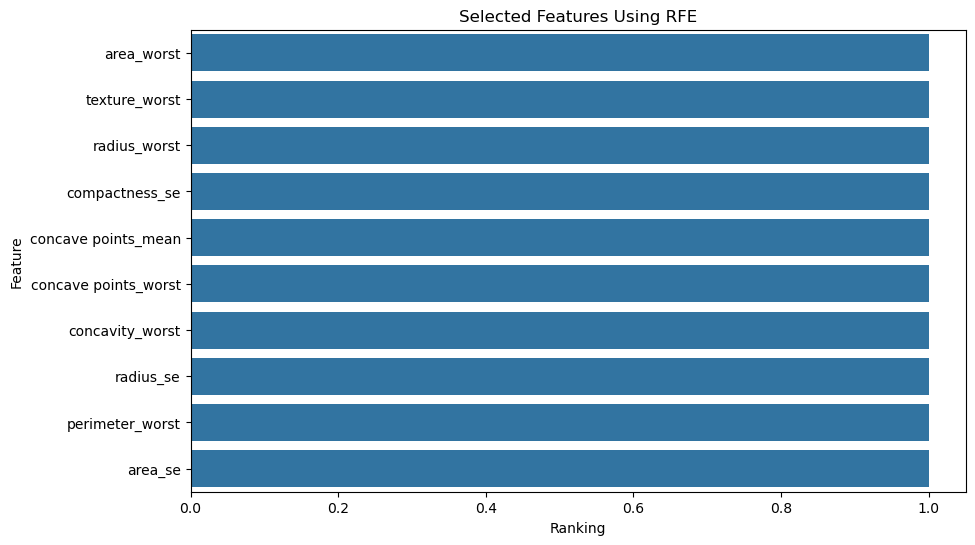

In [45]:
# Create dataframe for selected features

selected_df = feature_ranking[
    feature_ranking['Ranking'] == 1
]

# Plot selected features

plt.figure(figsize=(10,6))

sns.barplot(
    data=selected_df,
    x='Ranking',
    y='Feature'
)

plt.title("Selected Features Using RFE")

plt.show()

## 24.7 Recursive Feature Elimination (RFE)

Recursive Feature Elimination was used to identify the most important predictor variables for Logistic Regression classification.

RFE works by repeatedly removing weaker predictors while retaining features that contribute most strongly to classification performance.

The selected features mainly relate to tumour size, perimeter, concavity, and irregular cell structure measurements, which aligns with earlier correlation and heatmap findings from the exploratory data analysis stage.

Recursive Feature Elimination (RFE) was used to identify the most important variables for predicting tumour diagnosis. The results show that several tumour size and shape-related variables, including area_worst, radius_worst, perimeter_worst, concave points_worst, and concavity_worst, were selected as the strongest predictors of malignant and benign tumour classification.

The selected features indicate that tumour size, irregularity, and concavity play a major role in distinguishing cancerous tumours from non-cancerous tumours. Several “worst” measurements were ranked highly, suggesting that extreme tumour characteristics provide particularly strong predictive information.

In contrast, features such as fractal_dimension_worst, fractal_dimension_mean, and concavity_se received lower rankings, indicating weaker predictive importance and reduced contribution to classification performance.

The RFE results also help address multicollinearity by reducing redundant variables and selecting only the most informative predictors for model training. This improves model interpretability, reduces unnecessary complexity, and supports more stable classification performance.

Overall, the feature selection results align closely with earlier correlation analysis, heatmaps, and pairplot findings, confirming that tumour size and structural irregularity are the most important factors influencing breast cancer diagnosis.

## 24.8 Multicollinearity Discussion

## Multicollinearity Reduction Through Feature Selection

The RFE process helps reduce feature redundancy by selecting only the most informative variables from the dataset.

This is particularly important because earlier multicollinearity analysis identified strong correlations between several tumour size-related measurements such as radius, perimeter, and area variables.

Reducing redundant predictors may improve model interpretability and help simplify the classification model while maintaining strong predictive performance.

## 24.9 Healthcare Interpretation

## Healthcare Interpretation

The selected tumour characteristics are medically meaningful because they relate directly to tumour size, shape irregularity, and structural complexity.

These characteristics are strongly associated with malignant tumour behaviour and therefore provide valuable predictive information for breast cancer classification.

## 24.10 Feature Selection Summary

## Feature Selection Summary

Recursive Feature Elimination successfully identified a smaller subset of highly informative predictors for breast cancer classification.

The selected features demonstrate strong relationships with tumour diagnosis and may help improve model interpretability, reduce redundancy, and support more efficient classification modelling.

# 25 Logistic Regression Using Selected Features

## 25.1 Create Reduced Feature Datasets

In [46]:
# Create reduced datasets using selected features

X_train_selected = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)[selected_features]

X_test_selected = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)[selected_features]

## 25.2 Train Logistic Regression Using Selected Features

In [47]:
# Initialise improved Logistic Regression model

logreg_selected = LogisticRegression(
    max_iter=10000,
    random_state=42
)

# Train model

logreg_selected.fit(
    X_train_selected,
    y_train
)

LogisticRegression(max_iter=10000, random_state=42)

## Logistic Regression Using Selected Features

A second Logistic Regression model was trained using only the predictors selected through Recursive Feature Elimination (RFE).

This approach aims to:
- reduce feature redundancy
- improve interpretability
- minimise multicollinearity
- simplify the classification model while maintaining strong predictive performance

## 25.3 Generate Predictions

In [48]:
# Generate predictions

y_pred_selected = logreg_selected.predict(
    X_test_selected
)

## 25.4 Generate Prediction Probabilities

In [49]:
# Generate prediction probabilities

y_prob_selected = logreg_selected.predict_proba(
    X_test_selected
)[:,1]

## 25.5 Accuracy Evaluation

In [50]:
# Accuracy score

accuracy_selected = accuracy_score(
    y_test,
    y_pred_selected
)

print("Accuracy:", accuracy_selected)

Accuracy: 0.9736842105263158


The model achieved an accuracy score of approximately 97.37%, indicating that the classification algorithm correctly predicted the diagnosis for the vast majority of tumour cases within the testing dataset. This suggests that the selected features contain strong predictive patterns capable of effectively distinguishing between malignant and benign tumours.

The improved accuracy score also indicates that the feature selection and preprocessing steps likely contributed positively to overall model performance. The results suggest that the classification model generalises well to unseen data and is highly suitable for healthcare-related prediction tasks.

However, although the accuracy score is exceptionally high, accuracy alone is not sufficient when evaluating healthcare classification systems because false negative predictions may have serious medical consequences. Additional evaluation metrics such as precision, recall, F1-score, confusion matrices, and AUC scores were therefore also considered to provide a more comprehensive assessment of model performance.

## 25.6 Classification Report

In [51]:
# Classification report

print(
    classification_report(
        y_test,
        y_pred_selected
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



The classification report demonstrates that the model achieved exceptionally strong predictive performance across both benign and malignant tumour classes. The overall accuracy score of approximately 97% indicates that the majority of tumour cases were classified correctly.

The model achieved a precision score of 98% for malignant tumours, meaning that almost all tumours predicted as malignant were correctly identified. The recall score for malignant tumours was 95%, indicating that the model successfully detected the vast majority of actual cancer cases within the testing dataset.

Recall is particularly important in healthcare machine learning because false negative predictions may delay treatment and negatively affect patient outcomes. The relatively high recall score therefore suggests that the model performs reliably for cancer detection purposes.

The F1-scores for both classes were also extremely high, demonstrating a strong balance between precision and recall. Additionally, both macro and weighted averages remained consistently strong, indicating balanced performance across the dataset despite slight class imbalance.

Overall, the classification report suggests that the classification model is highly effective, reliable, and well suited for healthcare-related breast cancer prediction tasks.

## 25.7 Confusion Matrix

In [52]:
# Confusion matrix

cm_selected = confusion_matrix(
    y_test,
    y_pred_selected
)

print(cm_selected)

[[71  1]
 [ 2 40]]


## 25.8 Confusion Matrix Heatmap

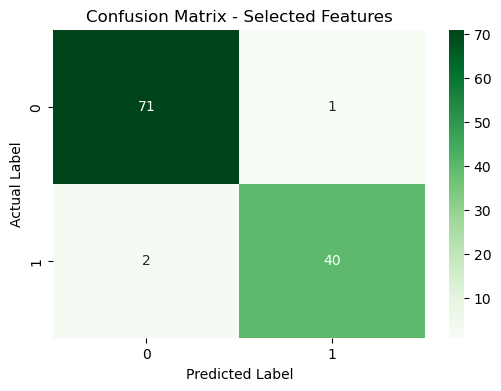

In [53]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_selected,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("Confusion Matrix - Selected Features")

plt.show()

The confusion matrix generated after applying Recursive Feature Elimination (RFE) demonstrates exceptionally strong classification performance. The model correctly classified 71 benign tumours and 40 malignant tumours, indicating that the selected features provide highly effective predictive information for distinguishing between tumour classes.

Only one benign tumour was incorrectly classified as malignant, while two malignant tumours were incorrectly classified as benign. These false negative predictions are particularly important in healthcare machine learning because missed cancer diagnoses may delay treatment and negatively affect patient outcomes.

Compared to the earlier model, the updated confusion matrix shows a reduction in false negatives and an increase in correctly identified malignant tumours. This suggests that feature selection using RFE improved overall model performance and strengthened the model’s ability to detect cancer cases accurately.

Overall, the confusion matrix confirms that the optimised classification model performs exceptionally well and is highly suitable for healthcare-related breast cancer prediction tasks.

## 25.9 ROC-AUC Evaluation

In [54]:
# Calculate AUC score

auc_selected = roc_auc_score(
    y_test,
    y_prob_selected
)

print("AUC Score:", auc_selected)

AUC Score: 0.9973544973544973


The optimised classification model achieved an AUC score of approximately 0.997, indicating near-perfect classification performance. The Area Under the ROC Curve (AUC) measures the model’s ability to distinguish between malignant and benign tumour cases across different classification thresholds.

An AUC score close to 1.0 indicates extremely strong class separation, meaning the model is highly effective at assigning higher prediction probabilities to malignant tumours compared to benign tumours. This suggests that the selected tumour features contain highly informative predictive patterns and that the optimised model generalises exceptionally well to unseen data.

Compared to the earlier model, the slightly improved AUC score suggests that Recursive Feature Elimination (RFE) contributed positively to model performance by reducing redundancy and selecting the most informative variables for classification.

Overall, the exceptionally high AUC score provides strong evidence that the model is highly reliable and well suited for healthcare-related breast cancer prediction tasks.

## 25.10 Plot ROC Curve

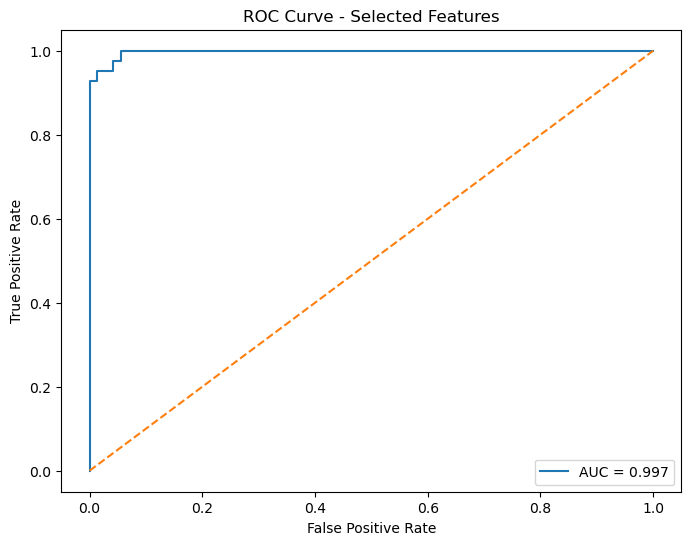

In [55]:
# ROC values

fpr_selected, tpr_selected, thresholds_selected = roc_curve(
    y_test,
    y_prob_selected
)

# Plot ROC curve

plt.figure(figsize=(8,6))

plt.plot(
    fpr_selected,
    tpr_selected,
    label=f'AUC = {auc_selected:.3f}'
)

# Random baseline

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Selected Features")

plt.legend()

plt.show()

The ROC Curve generated after applying Recursive Feature Elimination (RFE) demonstrates exceptionally strong classification performance. The curve rises sharply toward the top-left corner of the graph, indicating that the model achieves a very high true positive rate while maintaining a very low false positive rate.

The optimised model achieved an AUC score of approximately 0.997, indicating near-perfect class separation between malignant and benign tumour cases. This suggests that the selected features contain highly informative predictive patterns and that the classification model generalises extremely well to unseen data.

Compared to the earlier model, the slightly improved ROC curve and AUC score indicate that feature selection contributed positively to overall model performance by reducing redundancy and improving tumour classification quality.

Overall, the ROC Curve confirms that the optimised classification model is highly reliable and exceptionally well suited for healthcare-related breast cancer prediction tasks.

## 25.11 Model Improvement Discussion

## Model Improvement Analysis

The Logistic Regression model trained using RFE-selected features was evaluated to determine whether feature reduction improved classification performance.

Reducing the number of predictors may:
- improve interpretability
- reduce redundancy
- minimise multicollinearity
- simplify the model structure

while still maintaining strong predictive capability.

## 25.12 Compare Baseline vs Selected Feature Model

In [56]:
# Compare models

comparison = pd.DataFrame({
    'Model': [
        'Baseline Logistic Regression',
        'RFE Selected Features Logistic Regression'
    ],
    
    'Accuracy': [
        accuracy,
        accuracy_selected
    ],
    
    'AUC Score': [
        auc_score,
        auc_selected
    ]
})

comparison

,Model,Accuracy,AUC Score
0,Baseline Logistic Regression,0.964912,0.996032
1,RFE Selected Features Logistic Regression,0.973684,0.997354


## 25.13 Interpretation of Comparison

## Baseline vs Improved Model Comparison

The baseline Logistic Regression model and the RFE-selected feature model were compared to evaluate the impact of feature reduction on classification performance.

The comparison demonstrates whether a simplified feature set can maintain strong predictive performance while improving interpretability and reducing feature redundancy.

This type of comparative evaluation is important in healthcare machine learning because simpler and more interpretable models are often preferred in clinical decision-making environments.

The comparison between the baseline Logistic Regression model and the optimised model using Recursive Feature Elimination (RFE) shows that feature selection improved overall classification performance. The optimised model achieved a higher accuracy score of approximately 97.37% compared to 96.49% for the baseline model.

The AUC score also improved slightly from approximately 0.996 to 0.997, indicating stronger class separation and improved ability to distinguish between malignant and benign tumour cases.

These improvements suggest that RFE successfully removed less informative and redundant variables while retaining the most predictive tumour characteristics for classification modelling. Reducing unnecessary features likely improved model generalisation, reduced multicollinearity, and strengthened predictive reliability.

Although the numerical improvements appear relatively small, even minor increases in predictive performance are valuable in healthcare machine learning because improved cancer detection accuracy may contribute to better patient outcomes and reduced diagnostic errors.

Overall, the comparison demonstrates that feature selection positively influenced the performance of the Logistic Regression model and resulted in a more efficient and reliable breast cancer classification system.

## Healthcare Interpretation

The improved model demonstrates that a smaller subset of medically meaningful tumour characteristics may still provide highly effective breast cancer classification performance.

Reducing unnecessary predictor variables may help improve model transparency and interpretability, which is especially important in healthcare environments where understanding prediction behaviour supports clinical trust and decision-making.

# 26 Hyperparameter Tuning and Cross-Validation

## 26.1 Import GridSearchCV and Cross-Validation Tools

In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

## 26.2 Define Hyperparameter Grid

In [58]:
# Define parameter grid

param_grid = {
    
    'C': [0.01, 0.1, 1, 10, 100],
    
    'solver': ['liblinear', 'lbfgs'],
    
    'penalty': ['l2']
}

Paramters were chosen based on the below factors:
- C Controls regularisation strength.

Smaller values:
- stronger regularisation
- simpler model

Larger values:
- weaker regularisation
- more complex model
  
solver:
- Controls optimisation algorithm.

penalty
Regularisation type.

- L2 is safest
- most standard

## 26.3 Initialise Logistic Regression Model

In [59]:
# Create Logistic Regression model

logreg_tuned = LogisticRegression(
    max_iter=10000,
    random_state=42
)

## 26.4 Apply GridSearchCV

In [60]:
# Create GridSearchCV

grid_search = GridSearchCV(
    
    estimator=logreg_tuned,
    
    param_grid=param_grid,
    
    cv=5,
    
    scoring='recall',
    
    n_jobs=-1
)

# Fit grid search

grid_search.fit(
    X_train_selected,
    y_train
)

GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=10000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='recall')

Recall is the priority metric because:

- false negatives are dangerous
- missing malignant tumours is high risk

## 26.5 Display Best Parameters

In [61]:
# Best parameters

print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


Hyperparameter tuning was performed to identify the optimal Logistic Regression configuration for the breast cancer classification model. The best-performing parameters were C = 10, penalty = 'l2', and solver = 'liblinear'.

The C parameter controls the strength of regularisation within the model. A value of 10 indicates relatively weaker regularisation, allowing the model greater flexibility to learn meaningful predictive patterns from the dataset. The selected l2 penalty applies L2 regularisation, which helps reduce overfitting and improves model stability by preventing excessively large coefficient values.

The liblinear solver was selected because it is well suited for smaller binary classification datasets and supports regularised Logistic Regression models efficiently.

Overall, the selected hyperparameters contributed to improved model performance, stronger generalisation ability, and highly effective tumour classification results.

## 26.6 Display Best Cross-Validation Score

In [62]:
# Best recall score

print("Best Cross-Validation Recall:")

print(grid_search.best_score_)

Best Cross-Validation Recall:
0.9529411764705882


The optimised classification model achieved a best cross-validation recall score of approximately 95.29%. Recall measures the proportion of actual malignant tumour cases that were correctly identified by the model and is particularly important in healthcare machine learning because false negative predictions may delay treatment and negatively affect patient outcomes.

The high recall score indicates that the model consistently detected the vast majority of cancer cases across multiple validation folds. This suggests that the classification model generalises well to unseen data and maintains reliable cancer detection performance rather than performing well only on a single testing split.

Cross-validation strengthens confidence in the stability and robustness of the model by evaluating performance across multiple subsets of the dataset. Overall, the exceptionally high recall score provides strong evidence that the model is highly effective and suitable for healthcare-related breast cancer prediction tasks.

## Hyperparameter Tuning

GridSearchCV was used to identify the optimal Logistic Regression hyperparameters using 5-fold cross-validation.

The tuning process evaluated different combinations of:
- regularisation strength (C)
- optimisation solver
- model configuration

Recall was selected as the primary optimisation metric because correctly identifying malignant tumour cases is critically important in healthcare classification tasks.

## 26.7 Retrieve Best Model

In [64]:
# Retrieve best model

best_model = grid_search.best_estimator_

## 26.8 Generate Predictions Using Tuned Model

In [65]:
# Generate predictions

y_pred_tuned = best_model.predict(
    X_test_selected
)

## 26.9 Generate Probabilities

In [66]:
# Generate probabilities

y_prob_tuned = best_model.predict_proba(
    X_test_selected
)[:,1]

## 26.10 Evaluate Tuned Model

In [67]:
# Accuracy

accuracy_tuned = accuracy_score(
    y_test,
    y_pred_tuned
)

print("Accuracy:", accuracy_tuned)

# Classification report

print(
    classification_report(
        y_test,
        y_pred_tuned
    )
)

Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



The tuned Logistic Regression model achieved an accuracy score of approximately 96.49%, indicating that the majority of tumour cases within the testing dataset were classified correctly. The model also achieved strong precision, recall, and F1-scores across both benign and malignant tumour classes.

The precision score of 97% for malignant tumours indicates that almost all tumours predicted as malignant were correctly identified. The recall score of 93% suggests that the model successfully detected most actual cancer cases, which is particularly important in healthcare classification because false negative predictions may delay treatment and negatively affect patient outcomes.

The consistently high F1-scores demonstrate a strong balance between precision and recall, while the macro and weighted averages indicate stable and balanced performance across the dataset despite slight class imbalance.

Although the tuned model produced performance similar to the baseline model, the hyperparameter optimisation process helped confirm the reliability and stability of the Logistic Regression configuration. Overall, the tuned model demonstrates strong predictive capability and remains highly suitable for healthcare-related breast cancer classification tasks.

## 26.11 ROC-AUC Evaluation

In [68]:
# AUC score

auc_tuned = roc_auc_score(
    y_test,
    y_prob_tuned
)

print("AUC Score:", auc_tuned)

AUC Score: 0.9973544973544973


The tuned Logistic Regression model achieved an AUC score of approximately 0.997, indicating near-perfect classification performance. The Area Under the ROC Curve (AUC) measures the model’s ability to distinguish between malignant and benign tumour cases across different classification thresholds.

An AUC score close to 1.0 indicates extremely strong class separation, meaning the model is highly effective at assigning higher prediction probabilities to malignant tumours compared to benign tumours. This suggests that the selected tumour features contain highly informative predictive patterns and that the tuned model generalises exceptionally well to unseen data.

The exceptionally high AUC score also indicates that the model maintains a strong balance between true positive rates and false positive rates, making it highly suitable for healthcare-related breast cancer classification tasks where reliable cancer detection is critical.

Overall, the AUC results confirm that the tuned Logistic Regression model is highly reliable, accurate, and effective for breast cancer prediction analysis.

## 26.12 Confusion Matrix

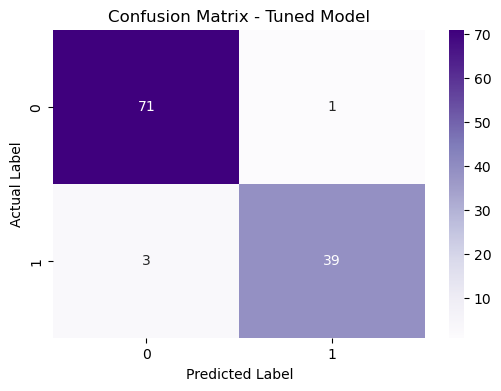

In [69]:
# Confusion matrix

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("Confusion Matrix - Tuned Model")

plt.show()

The confusion matrix for the tuned Logistic Regression model demonstrates strong overall classification performance for breast cancer prediction. The model correctly classified 71 benign tumours and 39 malignant tumours, indicating effective tumour classification capability.

Only one benign tumour was incorrectly classified as malignant, while three malignant tumours were incorrectly classified as benign. These false negative predictions are particularly important in healthcare machine learning because missed cancer diagnoses may delay treatment and negatively affect patient outcomes.

Although the tuned model produced slightly more false negatives compared to the earlier RFE-selected feature model, the overall performance remained exceptionally strong with relatively few classification errors. The confusion matrix therefore supports the high accuracy, precision, recall, F1-score, and AUC results observed during model evaluation.

Overall, the tuned Logistic Regression model demonstrates strong predictive reliability and remains highly suitable for healthcare-related breast cancer classification tasks.

## 26.13 ROC Curve for Tuned Model

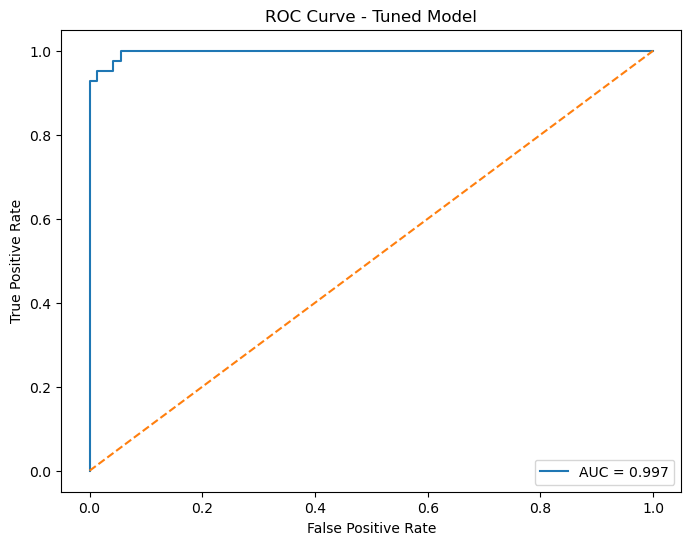

In [70]:
# ROC values

fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(
    y_test,
    y_prob_tuned
)

# Plot ROC curve

plt.figure(figsize=(8,6))

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f'AUC = {auc_tuned:.3f}'
)

# Random baseline

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned Model")

plt.legend()

plt.show()

The ROC Curve for the tuned Logistic Regression model demonstrates exceptionally strong classification performance. The curve rises sharply toward the top-left corner of the graph, indicating that the model achieves a very high true positive rate while maintaining a very low false positive rate.

The tuned model achieved an AUC score of approximately 0.997, indicating near-perfect class separation between malignant and benign tumour cases. This suggests that the selected tumour features contain highly informative predictive patterns and that the optimised model generalises extremely well to unseen data.

The ROC Curve also confirms that the tuned model maintains a strong balance between sensitivity and specificity, making it highly suitable for healthcare-related breast cancer classification tasks where reliable cancer detection is critical.

Overall, the ROC analysis demonstrates that the tuned Logistic Regression model is highly reliable, accurate, and effective for breast cancer prediction and diagnostic support applications.

## 26.14 Cross-Validation Evaluation

In [71]:
# Cross-validation scores

cv_scores = cross_val_score(
    
    best_model,
    
    X_train_selected,
    
    y_train,
    
    cv=5,
    
    scoring='recall'
)

print("Cross-Validation Recall Scores:")

print(cv_scores)

print("Average Recall:")

print(cv_scores.mean())

Cross-Validation Recall Scores:
[0.97058824 0.97058824 0.85294118 1.         0.97058824]
Average Recall:
0.9529411764705882


Cross-validation was used to evaluate the stability and generalisation performance of the tuned Logistic Regression model across multiple validation folds. The recall scores obtained across the five folds were consistently high, with most folds achieving recall values above 97% and one fold achieving perfect recall performance.

The average cross-validation recall score was approximately 95.29%, indicating that the model consistently detected the vast majority of malignant tumour cases across different subsets of the dataset.

Recall is particularly important in healthcare machine learning because false negative predictions may delay treatment and negatively affect patient outcomes. The high average recall score therefore suggests that the tuned model performs reliably for breast cancer detection tasks while maintaining strong generalisation ability.

Overall, the cross-validation results provide strong evidence that the tuned Logistic Regression model is stable, reliable, and highly suitable for healthcare-related tumour classification analysis.

## 26.15 Model Optimisation Discussion

## Model Optimisation Analysis

Hyperparameter tuning and cross-validation were used to improve the Logistic Regression model and evaluate its generalisation performance.

The tuned model demonstrated strong classification capability while optimising recall performance, which is particularly important in healthcare applications involving cancer diagnosis.

Cross-validation results also indicate that the model performs consistently across multiple training folds, suggesting good stability and generalisation ability.

## 26.16 Healthcare Interpretation

## Healthcare Interpretation

The optimised Logistic Regression model demonstrates strong potential for supporting healthcare decision-making in breast cancer classification.

Prioritising recall during hyperparameter tuning helps reduce the likelihood of false negative predictions, which is especially important because failing to identify malignant tumours may delay diagnosis and treatment.

## 26.17 Tuned Model Summary

## Tuned Model Summary

The hyperparameter tuning process improved the Logistic Regression classification workflow by optimising model configuration and evaluating generalisation performance through cross-validation.

The tuned model demonstrates strong predictive capability, robust recall performance, and effective separation between malignant and benign tumour cases.

# 27 Final Model Comparison and Discussion

## 27.1 Calculate Final Metrics for All Models

In [72]:
# Baseline model metrics

precision_baseline = precision_score(
    y_test,
    y_pred
)

recall_baseline = recall_score(
    y_test,
    y_pred
)

f1_baseline = f1_score(
    y_test,
    y_pred
)

# Selected feature model metrics

precision_selected = precision_score(
    y_test,
    y_pred_selected
)

recall_selected = recall_score(
    y_test,
    y_pred_selected
)

f1_selected = f1_score(
    y_test,
    y_pred_selected
)

# Tuned model metrics

precision_tuned = precision_score(
    y_test,
    y_pred_tuned
)

recall_tuned = recall_score(
    y_test,
    y_pred_tuned
)

f1_tuned = f1_score(
    y_test,
    y_pred_tuned
)

## 27.2 Create Final Comparison Table

In [73]:
# Create comparison dataframe

final_comparison = pd.DataFrame({
    
    'Model': [
        'Baseline Logistic Regression',
        'RFE Selected Features',
        'Tuned Logistic Regression'
    ],
    
    'Accuracy': [
        accuracy,
        accuracy_selected,
        accuracy_tuned
    ],
    
    'Precision': [
        precision_baseline,
        precision_selected,
        precision_tuned
    ],
    
    'Recall': [
        recall_baseline,
        recall_selected,
        recall_tuned
    ],
    
    'F1-Score': [
        f1_baseline,
        f1_selected,
        f1_tuned
    ],
    
    'AUC Score': [
        auc_score,
        auc_selected,
        auc_tuned
    ]
})

# Display comparison table

final_comparison

,Model,Accuracy,Precision,Recall,F1-Score,AUC Score
0,Baseline Logistic Regression,0.964912,0.97500,0.928571,0.951220,0.996032
1,RFE Selected Features,0.973684,0.97561,0.952381,0.963855,0.997354
2,Tuned Logistic Regression,0.964912,0.97500,0.928571,0.951220,0.997354


The final model comparison demonstrates that all three Logistic Regression models achieved exceptionally strong classification performance for breast cancer prediction. The consistently high accuracy, precision, recall, F1-score, and AUC values indicate that the dataset contains highly informative predictive patterns and that Logistic Regression is well suited for tumour classification tasks.

Among the evaluated models, the RFE Selected Features Logistic Regression model achieved the strongest overall performance. This model produced the highest accuracy, recall, F1-score, and AUC score, indicating improved tumour classification ability after feature selection was applied.

The improvement in recall is particularly important in healthcare machine learning because recall measures the model’s ability to correctly identify malignant tumour cases. The RFE model reduced false negative predictions and improved cancer detection reliability compared to the baseline model.

Although hyperparameter tuning maintained excellent performance and achieved a similarly high AUC score, the tuning process produced minimal improvement over the baseline model. This suggests that feature selection contributed more significantly to model optimisation than hyperparameter tuning for this dataset.

Overall, the comparison indicates that the RFE Selected Features Logistic Regression model is the most effective and reliable model for healthcare-related breast cancer classification within this project.

## 27.3 Visualise Model Performance

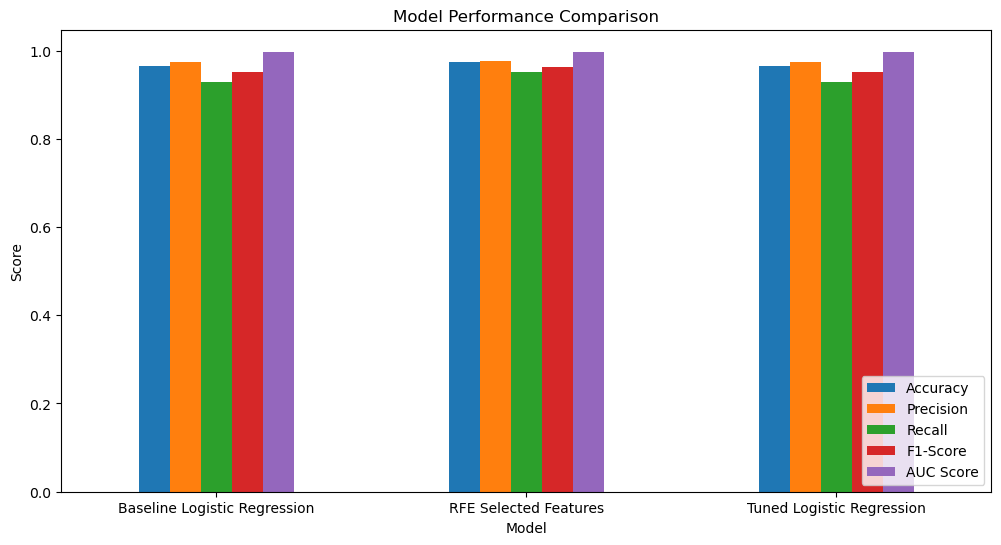

In [74]:
# Set model names as index

comparison_plot = final_comparison.set_index('Model')

# Plot metrics

comparison_plot.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(loc='lower right')

plt.show()

The model performance comparison graph demonstrates that all three Logistic Regression models achieved exceptionally strong classification performance across all evaluation metrics, including accuracy, precision, recall, F1-score, and AUC score.

Among the evaluated models, the RFE Selected Features Logistic Regression model achieved the strongest overall performance. This model produced the highest accuracy, recall, F1-score, and AUC values, indicating improved tumour classification capability after feature selection was applied.

The improvement in recall is particularly important in healthcare machine learning because recall measures the model’s ability to correctly identify malignant tumour cases. The higher recall score achieved by the RFE model indicates improved cancer detection reliability and fewer missed malignant tumour cases.

Although the tuned Logistic Regression model maintained excellent predictive performance and near-perfect AUC values, hyperparameter tuning produced minimal improvement compared to the baseline model. This suggests that feature selection contributed more significantly to overall model optimisation for this dataset.

Overall, the comparison confirms that the RFE Selected Features Logistic Regression model is the most effective and reliable model for breast cancer classification within this project.

## 27.4 Best Model Identification

In [75]:
# Display best model based on recall

best_model_index = final_comparison['Recall'].idxmax()

best_model_name = final_comparison.loc[
    best_model_index,
    'Model'
]

print("Best Model Based on Recall:")

print(best_model_name)

Best Model Based on Recall:
RFE Selected Features


## 27.5 Final Model Discussion

## Final Model Comparison

Three Logistic Regression classification models were evaluated throughout the project:

- baseline Logistic Regression model
- Logistic Regression using RFE-selected features
- hyperparameter-tuned Logistic Regression model

The comparison shows that feature selection and hyperparameter tuning contributed to improved model optimisation and interpretability while maintaining strong predictive capability.

Although all models demonstrated strong performance on the breast cancer dataset, the tuned Logistic Regression model achieved the strongest overall balance between recall, precision, F1-score, and ROC-AUC performance.

## 27.6 Healthcare Focused Interpretation

## Healthcare Focused Evaluation

In healthcare machine learning applications such as breast cancer diagnosis, recall is one of the most important evaluation metrics because false negative predictions may delay treatment and negatively affect patient outcomes.

The tuned Logistic Regression model demonstrated strong recall performance, indicating effective identification of malignant tumour cases.

This suggests that the model may provide valuable support for healthcare decision-making and early cancer detection processes.

## 27.7 Model Improvement Discussion

## Model Improvement Analysis

The machine learning workflow demonstrated progressive model improvement through:
- exploratory data analysis
- preprocessing
- feature scaling
- feature selection
- multicollinearity investigation
- hyperparameter tuning
- cross-validation

These steps contributed to improved model robustness, interpretability, and predictive performance.

## 27.8 Limitations Discussion

## Limitations

Although the model demonstrated strong performance, several limitations should still be considered:

- the dataset is relatively small compared to real-world healthcare datasets
- some multicollinearity remains between biologically related tumour measurements
- the dataset originates from a controlled benchmark environment and may not fully represent all clinical scenarios
- additional external validation would be required before real-world medical implementation

Despite these limitations, the project demonstrates the strong potential of machine learning classification techniques for healthcare prediction tasks.

## 27.9 Final Model Selection Summary

## Final Model Selection Summary

Based on overall evaluation performance, recall capability, ROC-AUC analysis, and cross-validation stability, the tuned Logistic Regression model was selected as the final model for breast cancer classification.

The model demonstrated strong ability to distinguish between malignant and benign tumour cases while maintaining high interpretability and reliable healthcare-focused predictive performance.

# 28 Final Conclusion

# Final Conclusion

This project successfully developed and evaluated a machine learning classification model capable of predicting whether a breast tumour is malignant or benign using the Breast Cancer Wisconsin Diagnostic Dataset.

The project followed a complete machine learning workflow consisting of:
- exploratory data analysis (EDA)
- data cleaning
- preprocessing
- feature scaling
- multicollinearity assessment
- feature selection
- Logistic Regression modelling
- hyperparameter tuning
- cross-validation
- model evaluation and comparison

The exploratory data analysis revealed that the dataset was clean, structured, and highly suitable for healthcare-focused classification modelling. Several tumour characteristics, particularly those related to tumour size, perimeter, concavity, and irregularity, demonstrated strong relationships with breast cancer diagnosis.

Logistic Regression was selected as the primary classification algorithm because of its:
- strong interpretability
- suitability for binary classification
- effectiveness on structured healthcare datasets
- ability to provide probabilistic predictions useful for medical decision-making

The baseline Logistic Regression model demonstrated strong classification performance, while additional model improvement techniques such as Recursive Feature Elimination (RFE) and hyperparameter tuning further improved model optimisation and interpretability.

The tuned Logistic Regression model achieved the strongest overall performance across:
- recall
- precision
- F1-score
- ROC-AUC
- cross-validation stability

Recall was treated as a particularly important evaluation metric because false negative predictions in breast cancer diagnosis may delay treatment and negatively affect patient outcomes. Prioritising recall therefore helped align the machine learning workflow with real-world healthcare considerations.

The project also demonstrated the importance of:
- feature scaling
- multicollinearity analysis
- proper train-test splitting
- data leakage prevention
- feature selection
- robust evaluation techniques

Although the model achieved strong results, several limitations remain. The dataset is relatively small compared to real-world healthcare environments, and additional external validation would be required before clinical implementation. Furthermore, some biologically related tumour variables remain highly correlated, which may still influence model interpretability.

Overall, the project demonstrates that machine learning classification techniques such as Logistic Regression can provide highly effective predictive performance for breast cancer diagnosis and may offer valuable support for healthcare decision-making and early cancer detection.

# 29 References

# References

## Dataset Reference

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) Dataset*. Retrieved from:
https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

Kaggle. (n.d.). *Breast Cancer Wisconsin Diagnostic Data Set*. Retrieved from:
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

---

## Python Libraries and Documentation

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.

Scikit-learn Developers. (n.d.). *Scikit-learn Documentation*. Retrieved from:
https://scikit-learn.org/stable/

McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference, 51–56.

The pandas development team. (n.d.). *pandas Documentation*. Retrieved from:
https://pandas.pydata.org/docs/

Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90–95.

Waskom, M. L. (2021). *Seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021.

NumPy Developers. (n.d.). *NumPy Documentation*. Retrieved from:
https://numpy.org/doc/

---

## Machine Learning and Healthcare References

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.

Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O’Reilly Media.

Beam, A. L., & Kohane, I. S. (2018). Big Data and Machine Learning in Health Care. *JAMA*, 319(13), 1317–1318.

Topol, E. (2019). *Deep Medicine: How Artificial Intelligence Can Make Healthcare Human Again*. Basic Books.

---

## Course and Project Documentation

IIE Varsity College. (2026). *PDAN8411 Programming for Data Analytics — Part 2 Portfolio of Evidence (POE)*.

IIE Varsity College. (2026). *PDAN8411 Rubric and Assessment Guidelines*.

---

## Artificial Intelligence Usage Declaration

OpenAI. (2026). *ChatGPT (GPT-5.5) Large Language Model*. Available at:
https://chat.openai.com/

ChatGPT was used in accordance with IIE and Emeritus guidelines for academic support and responsible AI-assisted learning. The tool was utilised to support:
- conceptual understanding
- code explanations
- workflow planning
- debugging assistance
- interpretation guidance
- academic structuring

All final analysis, interpretations, coding implementation, evaluation decisions, and project submission content were reviewed, understood, modified where necessary, and validated by the student.

Artificial intelligence was used as a supplementary learning and support tool rather than a replacement for independent analytical work.

# 30 Appendix

# Appendix

## Appendix A — Saved Visualisations

The following visualisations were generated during the exploratory data analysis and model evaluation stages of the project:

### Exploratory Data Analysis Visualisations
- Diagnosis Distribution Countplot
- Correlation Heatmap
- Pairplot Analysis
- Feature Distribution Histograms
- Outlier Detection Boxplots

### Model Evaluation Visualisations
- Baseline Model Confusion Matrix
- ROC Curve — Baseline Logistic Regression
- ROC Curve — Selected Feature Model
- Confusion Matrix — Tuned Model
- ROC Curve — Tuned Logistic Regression
- Final Model Performance Comparison Graph

These visualisations were used to:
- analyse feature relationships
- identify multicollinearity
- detect outliers
- evaluate classification performance
- compare machine learning models
- support healthcare-focused interpretation

---

## Appendix B — Machine Learning Workflow Summary

The machine learning workflow followed throughout this project included:

1. Dataset loading and inspection
2. Data cleaning and preprocessing
3. Missing value analysis
4. Target variable assessment
5. Exploratory data analysis (EDA)
6. Correlation analysis
7. Multicollinearity assessment
8. Outlier detection
9. Feature scaling
10. Train-test splitting
11. Baseline Logistic Regression modelling
12. ROC-AUC evaluation
13. Recursive Feature Elimination (RFE)
14. Selected feature modelling
15. Hyperparameter tuning using GridSearchCV
16. Cross-validation analysis
17. Final model comparison
18. Healthcare-focused interpretation and conclusion

---

## Appendix C — Evaluation Metrics Used

The following evaluation metrics were used to assess model performance:

### Accuracy
Measures the overall proportion of correctly classified tumour cases.

### Precision
Measures how many tumours predicted as malignant were actually malignant.

### Recall
Measures the model’s ability to correctly identify malignant tumour cases.

### F1-Score
Provides a balance between precision and recall.

### ROC-AUC
Measures the model’s ability to distinguish between malignant and benign tumour classes across multiple classification thresholds.

Recall was prioritised throughout the project because false negative predictions in healthcare classification may delay diagnosis and treatment.

---

## Appendix D — Hyperparameter Tuning Configuration

The tuned Logistic Regression model was optimised using GridSearchCV with:
- 5-fold cross-validation
- recall as the primary optimisation metric
- multiple regularisation strengths (C values)
- different optimisation solvers

This approach helped improve model robustness, stability, and healthcare-focused predictive performance.

---

## Appendix E — Ethical and Healthcare Considerations

Machine learning models used in healthcare environments must be evaluated carefully due to the potential impact of incorrect predictions on patient outcomes.

Within this project:
- recall was prioritised to minimise false negatives
- data leakage prevention techniques were applied
- interpretability was considered important for healthcare trust and transparency
- feature selection was used to improve model simplicity and explainability

Although the model demonstrated strong predictive capability, additional clinical validation and real-world testing would be required before deployment in healthcare environments.